# Example: Expectation values with FiQCIEstimator

For configuration options, mitigation levels, and result methods, see the [FiQCIEstimator guide](../pages/FiQCIEstimatorUsage.rst).

## Import everything needed

In [1]:
from fiqci.ems import FiQCIEstimator
from iqm.qiskit_iqm import IQMProvider
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp

## Initialise FiQCIEstimator

In [2]:
url = None
quantum_computer = None

# Connect to an IQM quantum computer using the provider
if url is not None and quantum_computer is not None:
	provider = IQMProvider(url=url, quantum_computer=quantum_computer)
	backend = provider.get_backend()
else:
	# Or using a noisy simulator
	from iqm.qiskit_iqm import IQMFakeAdonis

	backend = IQMFakeAdonis()

# Initialise FiQCI estimator with mitigation level 1 (readout error mitigation)
estimator = FiQCIEstimator(backend=backend, mitigation_level=1)

# We can view the default settings enabled for mitigation level 1
estimator.mitigator_options

{'zne': {'enabled': False,
  'fold_gates': None,
  'scale_factors': [1, 3, 5],
  'folding_method': 'local',
  'extrapolation_method': 'exponential',
  'extrapolation_degree': None},
 'rem': {'enabled': True,
  'calibration_shots': 1000,
  'calibration_file': None,
  'mitigator': <fiqci.ems.mitigators.rem.M3IQM at 0x77b8f83687a0>}}

## Bell State expectation values with REM

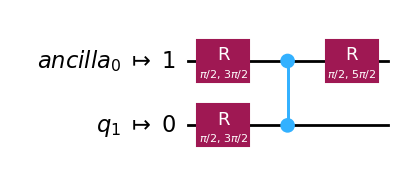

In [3]:
# Create a Bell state circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# Transpile for backend
qc_transpiled = transpile(qc, backend=backend, optimization_level=3)

qc_transpiled.draw("mpl")

In [4]:
# Define observables to calculate expectation values for
observables = SparsePauliOp.from_list([("ZZ", 1), ("IX", 1)])

# Map observables to the layout of the transpiled circuit
observables_device = observables.apply_layout(qc_transpiled.layout)

# Execute on FiQCI Estimator with specified observables and shots
job = estimator.run([qc_transpiled], observables=observables_device, shots=2**10)

# Retrieve mitigated expectation values
job.expectation_values()

[[0.949119373776908, 0.016617790811339198]]

## Access job metadata

In [5]:
# Get all jobs
jobs = job.jobs()

# Get the first job
job0 = jobs[0]

# Access raw counts for the first job
raw_counts = job0.result().results[0].header["fiqci_ems"]["raw_counts"]

print(raw_counts)

{'11': 449, '10': 52, '00': 469, '01': 54}


## Manually configure mitigation options

In [6]:
# Initialise FiQCI sampler
estimator = FiQCIEstimator(backend=backend, mitigation_level=0)

# Config rem
estimator.rem(enabled=True, calibration_shots=2**10)

# Print current mitigator options
estimator.mitigator_options

{'zne': {'enabled': False,
  'fold_gates': None,
  'scale_factors': [1, 3, 5],
  'folding_method': 'local',
  'extrapolation_method': 'exponential',
  'extrapolation_degree': None},
 'rem': {'enabled': True,
  'calibration_shots': 1024,
  'calibration_file': None,
  'mitigator': <fiqci.ems.mitigators.rem.M3IQM at 0x77b8f83d3e90>}}

## Access Job Information and Metadata

In [ ]:
# Estimator may execute multiple circuits depending on observables and mitigator settings. Here we fecth them all as a list
jobs = job.jobs()

# Look at the first job
job0 = jobs[0]

# Get the counts for the first job
print(job0.result().get_counts())

#Get raw counts for the circuit in the first job
print(job0.result().results[0].header)

raw_counts = job0.result().results[0].header["fiqci_ems"]["raw_counts"]

print(raw_counts)

[{'10': 10, '01': 16, '11': 489, '00': 507}, {'1': 503, '0': 520}]
{'creg_sizes': [['meas', 2]], 'global_phase': 0.0, 'memory_slots': 2, 'n_qubits': 5, 'name': 'circuit-13855', 'qreg_sizes': [['ancilla', 3], ['q', 2]], 'metadata': {}, 'fiqci_ems': {'mitigation_level': 1, 'mitigation_method': 'M3', 'calibration_shots': 1000, 'raw_counts': {'11': 449, '10': 52, '00': 469, '01': 54}}}
{'11': 449, '10': 52, '00': 469, '01': 54}
